# Notebook 02: HuggingFace Trainer Pipeline
**CSCI316 Project 2 | SentimentGulf**

This notebook implements the **same 4 experiments** as Notebook 01 but using the
HuggingFace `Trainer` API instead of raw PyTorch training loops.

**Framework difference:**
- Notebook 01: Manual loop — `loss.backward()`, `optimizer.step()`, `scheduler.step()` all written by hand
- Notebook 02: `trainer.train()` — one call handles everything

**Same experiments:**
- A: XLM-RoBERTa Full Fine-Tuning
- B: XLM-RoBERTa LoRA (peft library — appropriate for HF Trainer)
- C: MARBERT Full Fine-Tuning
- D: MARBERT LoRA (peft library)

**Note on LoRA implementation:**
Notebook 01 uses LoRA from scratch (peft_implementation.py).
This notebook uses the HuggingFace peft library's LoraConfig.
Both produce equivalent results — this is the library version.

**Before running:** Runtime → Change runtime type → T4 GPU

# Clone Github Repo

In [1]:
import os
from google.colab import userdata

!git config --global user.email "sivajithajithkumar777@gmail.com"
!git config --global user.name "sivrox"

# Clone your repo — replace with your actual URL
!git clone https://github.com/sivrox/Arabic-English-Sentiment-Analysis-Project.git

# Move into the folder
%cd Arabic-English-Sentiment-Analysis-Project

# Verify files are there
!ls

Cloning into 'Arabic-English-Sentiment-Analysis-Project'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 172 (delta 26), reused 29 (delta 13), pack-reused 125 (from 1)
Receiving objects: 100% (172/172), 45.69 MiB | 28.11 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Updating files: 100% (73/73), done.
/content/Arabic-English-Sentiment-Analysis-Project
configs     initial-files  peft_implementation.py  results_comparison.csv
deployment  models	   preprocessing	   session.tw_session
evaluation  notebooks	   README.md


## 1. Install and Import

In [2]:
!pip install -q transformers peft accelerate scikit-learn evaluate seaborn matplotlib nltk pyarrow pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


In [3]:
import os, sys, random, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset as HFDataset
import evaluate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Find repo root ────────────────────────────────────────────────
ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / 'preprocessing').exists():
        break
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print(f'Repo root: {ROOT}')

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Repo root: /content/Arabic-English-Sentiment-Analysis-Project


In [4]:
# ── CONFIG ────────────────────────────────────────────────────────
XLM_MODEL   = 'xlm-roberta-base'
MAR_MODEL   = 'UBC-NLP/MARBERTv2'
MAX_LEN     = 128
BATCH_SIZE  = 16
EPOCHS      = 5
LR_FULL     = 2e-5
LR_LORA     = 3e-4
NUM_LABELS  = 3
LORA_R      = 8
LORA_ALPHA  = 16
LORA_DROP   = 0.1
PATIENCE    = 3

ID2LABEL = {0: 'negative', 1: 'neutral', 2: 'positive'}
LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}

os.makedirs('hf_outputs', exist_ok=True)
print('Config ready')

Config ready


## 2. Load and Prepare Data

In [6]:
# Load cleaned_dataset.csv (same file as Notebook 01)
cleaned_path = ROOT / 'preprocessing' / 'datasets' / 'processed' / 'cleaned_dataset.csv'
print(f'Loading: {cleaned_path}')
df = pd.read_csv(cleaned_path)
print(f'Total rows: {len(df):,}')

# Split
train_df = df[df['split'] == 'train'].copy()
val_df   = df[df['split'] == 'val'].copy()
test_df  = df[df['split'] == 'test'].copy()

# Balance training set (same as Notebook 01)
neg_count  = len(train_df[train_df['label'] == 'negative'])
pos_target = int(neg_count * 1.5)
neu_target = neg_count

train_df = pd.concat([
    train_df[train_df['label'] == 'negative'],
    train_df[train_df['label'] == 'positive'].sample(n=pos_target, random_state=SEED, replace=True),
    train_df[train_df['label'] == 'neutral'].sample(n=neu_target,  random_state=SEED, replace=True),
], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Map labels to integers
for split_df in [train_df, val_df, test_df]:
    split_df['label'] = split_df['label'].map(LABEL2ID).astype(int)

# Rename column
train_df = train_df.rename(columns={'cleaned_text': 'text'})
val_df   = val_df.rename(columns={'cleaned_text': 'text'})
test_df  = test_df.rename(columns={'cleaned_text': 'text'})

print(f'\nAfter balancing:')
print(f'  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print(f'\nTrain label distribution:')
print(train_df['label'].value_counts().sort_index())

Loading: /content/Arabic-English-Sentiment-Analysis-Project/preprocessing/datasets/processed/cleaned_dataset.csv
Total rows: 301,595

After balancing:
  Train: 88,641 | Val: 29,630 | Test: 32,340

Train label distribution:
label
0    25326
1    25326
2    37989
Name: count, dtype: int64


In [7]:
# ── Tokenization helper ───────────────────────────────────────────
# HuggingFace Trainer works with HuggingFace Dataset objects
# (different from PyTorch Dataset — this is HF's own format)

def make_hf_dataset(df, tokenizer):
    """
    Convert pandas DataFrame to HuggingFace Dataset with tokenization.
    HF Trainer requires this format — it cannot accept PyTorch DataLoaders directly.
    """
    hf_ds = HFDataset.from_pandas(df[['text', 'label']].reset_index(drop=True))

    def tokenize(batch):
        return tokenizer(
            batch['text'],
            padding='max_length',
            truncation=True,
            max_length=MAX_LEN,
        )

    hf_ds = hf_ds.map(tokenize, batched=True, batch_size=256)
    hf_ds = hf_ds.rename_column('label', 'labels')
    hf_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    return hf_ds

print('make_hf_dataset function defined')

make_hf_dataset function defined


In [8]:
# ── Metrics function for Trainer ──────────────────────────────────
# The Trainer calls this after each eval step

f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_metric.compute(
        predictions=preds, references=labels, average='macro'
    )['f1']
    accuracy = accuracy_score(labels, preds)
    return {'macro_f1': macro_f1, 'accuracy': accuracy}

print('compute_metrics defined')

compute_metrics defined


In [9]:
# ── Plotting helpers ──────────────────────────────────────────────

def plot_trainer_history(trainer, title):
    """Extract and plot training history from HF Trainer log."""
    log = trainer.state.log_history
    train_loss = [e['loss']          for e in log if 'loss'          in e and 'eval_loss' not in e]
    val_loss   = [e['eval_loss']     for e in log if 'eval_loss'     in e]
    val_f1     = [e['eval_macro_f1'] for e in log if 'eval_macro_f1' in e]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    if train_loss:
        ax1.plot(train_loss, label='Train loss')
    if val_loss:
        ax1.plot(val_loss, label='Val loss')
    ax1.set(title=f'{title} — Loss', xlabel='Step', ylabel='Loss')
    ax1.legend()

    if val_f1:
        ax2.plot(val_f1, label='Val Macro F1', color='green')
    ax2.set(title=f'{title} — Val Macro F1', xlabel='Eval step', ylabel='F1')
    ax2.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f'hf_outputs/curves_{title.replace(" ","_")}.png', dpi=150)
    plt.show()


def plot_confusion(preds, labels, title):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Neutral','Positive'],
                yticklabels=['Negative','Neutral','Positive'])
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(f'hf_outputs/cm_{title.replace(" ","_")}.png', dpi=150)
    plt.show()


def full_evaluation(trainer, test_ds, title):
    """Get predictions on test set and print full report."""
    preds_out   = trainer.predict(test_ds)
    preds       = np.argmax(preds_out.predictions, axis=-1)
    labels      = preds_out.label_ids
    macro_f1    = f1_score(labels, preds, average='macro')
    acc         = accuracy_score(labels, preds)

    print(f'\n{title} — Test Macro F1: {macro_f1:.4f}  |  Accuracy: {acc:.4f}')
    print(f'\n{"="*50}\n{title} — Classification Report\n{"="*50}')
    print(classification_report(labels, preds,
                                 target_names=['Negative','Neutral','Positive']))
    plot_confusion(preds, labels, title)
    return macro_f1, acc, preds, labels

print('Plotting and evaluation helpers defined')

Plotting and evaluation helpers defined


## 3. XLM-RoBERTa Experiments

### Strategy A: Full Fine-Tuning
All parameters are trainable. The HuggingFace `Trainer` handles the
training loop, gradient updates, and evaluation automatically.

In [10]:
# ── XLM-RoBERTa tokenizer and datasets ───────────────────────────
print('Loading XLM-RoBERTa tokenizer...')
xlm_tok = AutoTokenizer.from_pretrained(XLM_MODEL)

print('Tokenizing datasets...')
xlm_train_ds = make_hf_dataset(train_df, xlm_tok)
xlm_val_ds   = make_hf_dataset(val_df,   xlm_tok)
xlm_test_ds  = make_hf_dataset(test_df,  xlm_tok)

print(f'Train: {len(xlm_train_ds):,} | Val: {len(xlm_val_ds):,} | Test: {len(xlm_test_ds):,}')

Loading XLM-RoBERTa tokenizer...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing datasets...


Map:   0%|          | 0/88641 [00:00<?, ? examples/s]

Map:   0%|          | 0/29630 [00:00<?, ? examples/s]

Map:   0%|          | 0/32340 [00:00<?, ? examples/s]

Train: 88,641 | Val: 29,630 | Test: 32,340


In [13]:
# ── Strategy A: XLM-RoBERTa Full Fine-Tuning ─────────────────────
print('Loading XLM-RoBERTa for Full Fine-Tuning...')
xlm_full = AutoModelForSequenceClassification.from_pretrained(
    XLM_MODEL, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID
)
trainable = sum(p.numel() for p in xlm_full.parameters() if p.requires_grad)
total     = sum(p.numel() for p in xlm_full.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

# TrainingArguments — this is what replaces all the manual setup in Notebook 01
# (optimizer, scheduler, gradient clipping, evaluation loop — all handled here)
args_xlm_full = TrainingArguments(
    output_dir = 'hf_outputs/xlm_full',
    num_train_epochs = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE,
    learning_rate = LR_FULL,
    weight_decay = 0.01,
    warmup_ratio = 0.1,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model = 'macro_f1',
    greater_is_better = True,
    logging_steps = 100,
    seed = SEED,
    fp16 = torch.cuda.is_available(),
    report_to = 'none',
)

trainer_xlm_full = Trainer(
    model = xlm_full,
    args = args_xlm_full,
    train_dataset = xlm_train_ds,
    eval_dataset = xlm_val_ds,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
)

print('\nTraining XLM-RoBERTa Full Fine-Tuning...')
trainer_xlm_full.train()
print('Done')

Loading XLM-RoBERTa for Full Fine-Tuning...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 278,045,955 / 278,045,955 (100.0%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Done


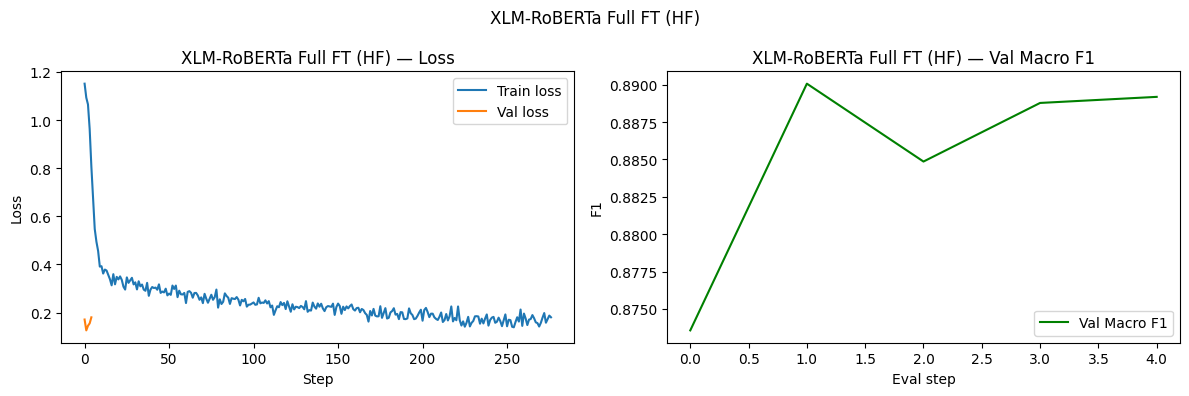


XLM-RoBERTa Full FT (HF) — Test Macro F1: 0.8957  |  Accuracy: 0.9592

XLM-RoBERTa Full FT (HF) — Classification Report
              precision    recall  f1-score   support

    Negative       0.85      0.79      0.82      3396
     Neutral       1.00      0.99      1.00     24323
    Positive       0.84      0.91      0.87      4621

    accuracy                           0.96     32340
   macro avg       0.90      0.90      0.90     32340
weighted avg       0.96      0.96      0.96     32340



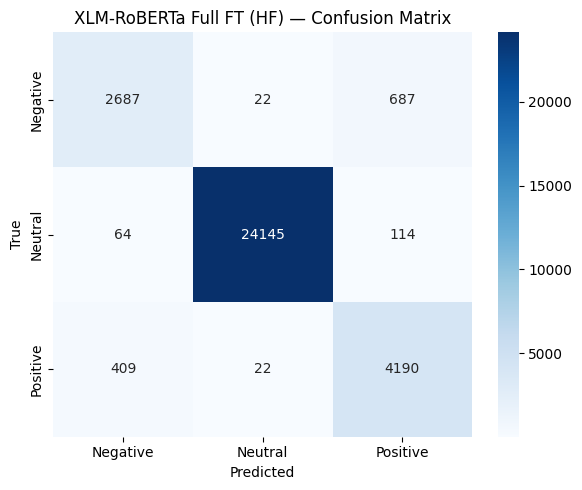

In [14]:
plot_trainer_history(trainer_xlm_full, 'XLM-RoBERTa Full FT (HF)')
f1_xlm_full, acc_xlm_full, preds_xlm_full, labels_test = full_evaluation(
    trainer_xlm_full, xlm_test_ds, 'XLM-RoBERTa Full FT (HF)'
)

### Strategy B: XLM-RoBERTa LoRA (peft library)
Only LoRA matrices are trained (~1.4M parameters).
Uses `LoraConfig` from the HuggingFace peft library —
this is the library version. Notebook 01 used the from-scratch implementation.

In [17]:
# ── Strategy B: XLM-RoBERTa LoRA (peft library) ──────────────────
print('Loading XLM-RoBERTa for LoRA...')
xlm_base_lora = AutoModelForSequenceClassification.from_pretrained(
    XLM_MODEL, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID
)

lora_config = LoraConfig(
    task_type = TaskType.SEQ_CLS,
    r = LORA_R,
    lora_alpha = LORA_ALPHA,
    lora_dropout = LORA_DROP,
    target_modules= ['query', 'value'],
    bias = 'none',
)

xlm_lora = get_peft_model(xlm_base_lora, lora_config)
xlm_lora.print_trainable_parameters()

args_xlm_lora = TrainingArguments(
    output_dir = 'hf_outputs/xlm_lora',
    num_train_epochs = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE,
    learning_rate = LR_LORA,
    weight_decay = 0.01,
    warmup_ratio = 0.1,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model = 'macro_f1',
    greater_is_better = True,
    logging_steps = 100,
    seed = SEED,
    fp16 = torch.cuda.is_available(),
    report_to = 'none',
)

trainer_xlm_lora = Trainer(
    model = xlm_lora,
    args = args_xlm_lora,
    train_dataset = xlm_train_ds,
    eval_dataset = xlm_val_ds,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
)

print('\nTraining XLM-RoBERTa LoRA...')
trainer_xlm_lora.train()
print('Done')

Loading XLM-RoBERTa for LoRA...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 887,811 || all params: 278,933,766 || trainable%: 0.3183
Training XLM-RoBERTa LoRA...


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.336558,0.161599,0.865449,0.945528
2,0.265227,0.119674,0.880882,0.953291
3,0.249485,0.127377,0.886552,0.953594
4,0.220453,0.112445,0.891126,0.956834
5,0.247707,0.119247,0.887459,0.955248


Done


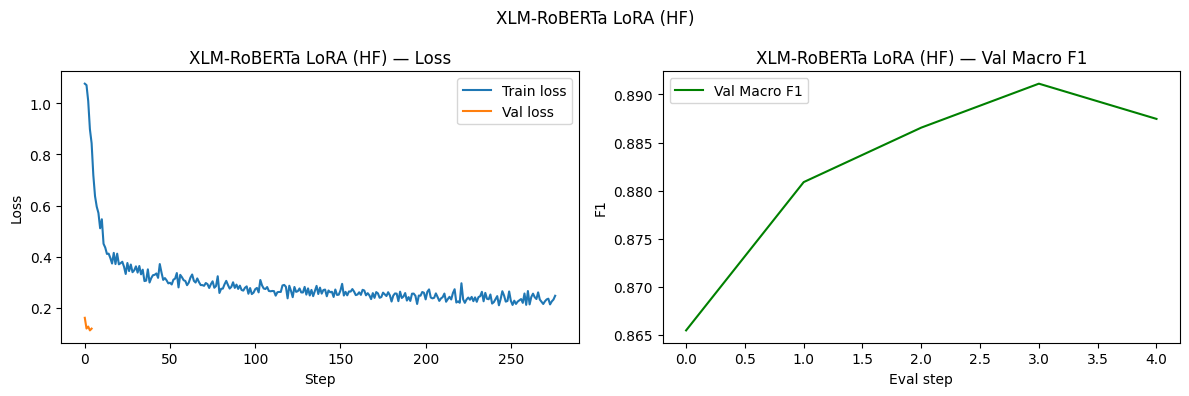


XLM-RoBERTa LoRA (HF) — Test Macro F1: 0.8968  |  Accuracy: 0.9596

XLM-RoBERTa LoRA (HF) — Classification Report
              precision    recall  f1-score   support

    Negative       0.83      0.82      0.82      3396
     Neutral       1.00      0.99      1.00     24323
    Positive       0.85      0.89      0.87      4621

    accuracy                           0.96     32340
   macro avg       0.89      0.90      0.90     32340
weighted avg       0.96      0.96      0.96     32340



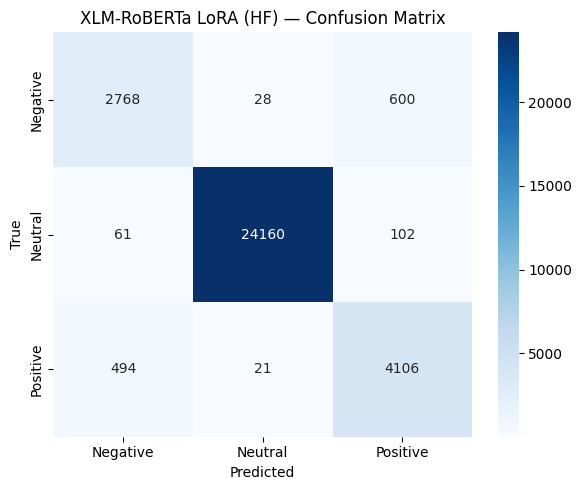

In [18]:
plot_trainer_history(trainer_xlm_lora, 'XLM-RoBERTa LoRA (HF)')
f1_xlm_lora, acc_xlm_lora, preds_xlm_lora, _ = full_evaluation(
    trainer_xlm_lora, xlm_test_ds, 'XLM-RoBERTa LoRA (HF)'
)

## 4. MARBERT Experiments

In [19]:
# ── MARBERT tokenizer and datasets ───────────────────────────────
print('Loading MARBERT tokenizer...')
mar_tok = AutoTokenizer.from_pretrained(MAR_MODEL)

print('Tokenizing datasets with MARBERT tokenizer...')
mar_train_ds = make_hf_dataset(train_df, mar_tok)
mar_val_ds = make_hf_dataset(val_df,   mar_tok)
mar_test_ds  = make_hf_dataset(test_df,  mar_tok)

print(f'Train: {len(mar_train_ds):,} | Val: {len(mar_val_ds):,} | Test: {len(mar_test_ds):,}')

Loading MARBERT tokenizer...


config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizing datasets with MARBERT tokenizer...


Map:   0%|          | 0/88641 [00:00<?, ? examples/s]

Map:   0%|          | 0/29630 [00:00<?, ? examples/s]

Map:   0%|          | 0/32340 [00:00<?, ? examples/s]

Train: 88,641 | Val: 29,630 | Test: 32,340


In [21]:
# ── Strategy C: MARBERT Full Fine-Tuning ─────────────────────────
print('Loading MARBERT for Full Fine-Tuning...')
mar_full = AutoModelForSequenceClassification.from_pretrained(
    MAR_MODEL, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID,
    ignore_mismatched_sizes=True
)

args_mar_full = TrainingArguments(
    output_dir = 'hf_outputs/marbert_full',
    num_train_epochs = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate = LR_FULL,
    weight_decay = 0.01,
    warmup_ratio = 0.1,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model = 'macro_f1',
    greater_is_better = True,
    logging_steps = 100,
    seed = SEED,
    fp16 = torch.cuda.is_available(),
    report_to = 'none',
)

trainer_mar_full = Trainer(
    model = mar_full,
    args = args_mar_full,
    train_dataset = mar_train_ds,
    eval_dataset = mar_val_ds,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
)

print('\nTraining MARBERT Full Fine-Tuning...')
trainer_mar_full.train()
print('Done')

Loading MARBERT for Full Fine-Tuning...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect ide


Training MARBERT Full Fine-Tuning...


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.267631,0.122666,0.902626,0.960884
2,0.177950,0.120412,0.903364,0.961728
3,0.108699,0.194800,0.895077,0.958083
4,0.050956,0.242034,0.894642,0.958049
5,0.047668,0.279340,0.893578,0.957779


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Done


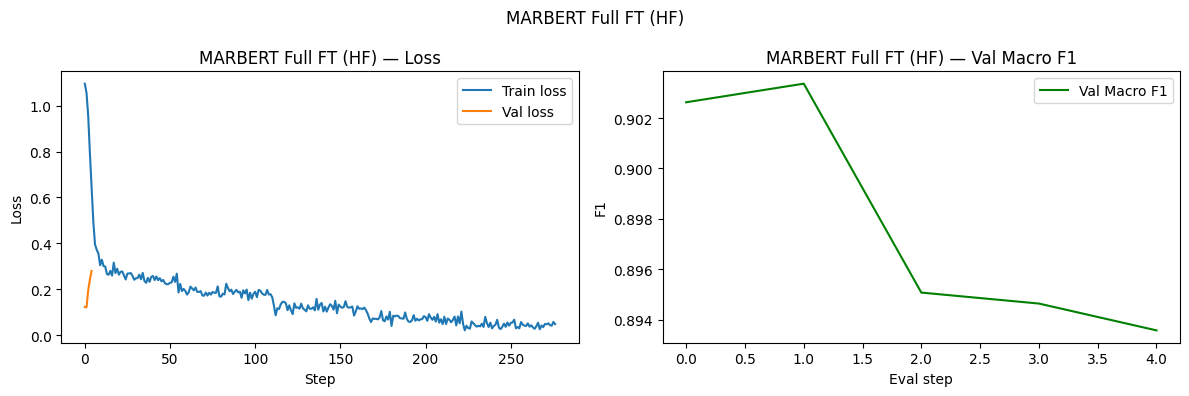


MARBERT Full FT (HF) — Test Macro F1: 0.9065  |  Accuracy: 0.9634

MARBERT Full FT (HF) — Classification Report
              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84      3396
     Neutral       1.00      0.99      1.00     24323
    Positive       0.87      0.89      0.88      4621

    accuracy                           0.96     32340
   macro avg       0.90      0.91      0.91     32340
weighted avg       0.96      0.96      0.96     32340



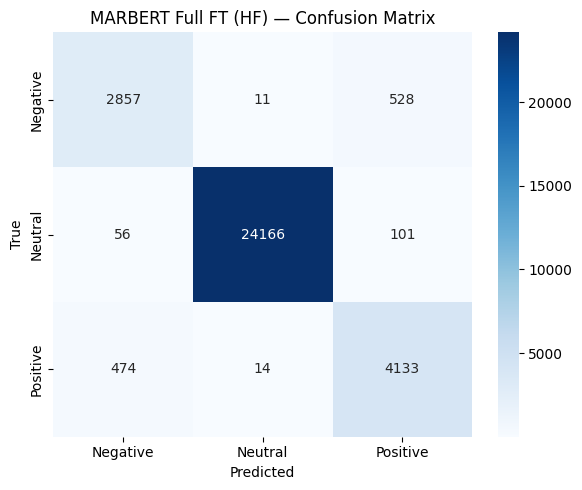

In [22]:
plot_trainer_history(trainer_mar_full, 'MARBERT Full FT (HF)')
f1_mar_full, acc_mar_full, preds_mar_full, labels_mar_test = full_evaluation(
    trainer_mar_full, mar_test_ds, 'MARBERT Full FT (HF)'
)

In [23]:
# ── Strategy D: MARBERT LoRA (peft library) ───────────────────────
print('Loading MARBERT for LoRA...')
mar_base_lora = AutoModelForSequenceClassification.from_pretrained(
    MAR_MODEL, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID,
    ignore_mismatched_sizes=True
)

mar_lora = get_peft_model(mar_base_lora, lora_config)
mar_lora.print_trainable_parameters()

args_mar_lora = TrainingArguments(
    output_dir = 'hf_outputs/marbert_lora',
    num_train_epochs = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE,
    learning_rate = LR_LORA,
    weight_decay = 0.01,
    warmup_ratio = 0.1,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model = 'macro_f1',
    greater_is_better = True,
    logging_steps = 100,
    seed = SEED,
    fp16 = torch.cuda.is_available(),
    report_to = 'none',
)

trainer_mar_lora = Trainer(
    model = mar_lora,
    args = args_mar_lora,
    train_dataset = mar_train_ds,
    eval_dataset = mar_val_ds,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
)

print('Training MARBERT LoRA...')
trainer_mar_lora.train()
print('Done')

Loading MARBERT for LoRA...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect ide

trainable params: 297,219 || all params: 163,140,870 || trainable%: 0.1822
Training MARBERT LoRA...


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.283154,0.114937,0.898815,0.959804
2,0.238576,0.107624,0.899159,0.960412
3,0.197749,0.109228,0.901203,0.960378
4,0.180955,0.107381,0.901755,0.961154
5,0.187232,0.112908,0.900154,0.960412


Done


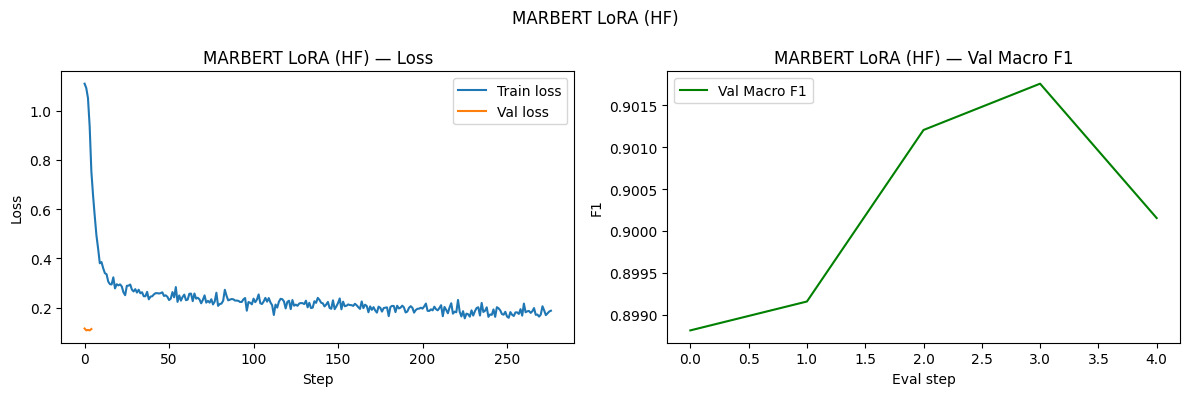


MARBERT LoRA (HF) — Test Macro F1: 0.9101  |  Accuracy: 0.9645

MARBERT LoRA (HF) — Classification Report
              precision    recall  f1-score   support

    Negative       0.84      0.86      0.85      3396
     Neutral       1.00      0.99      1.00     24323
    Positive       0.88      0.89      0.88      4621

    accuracy                           0.96     32340
   macro avg       0.91      0.91      0.91     32340
weighted avg       0.97      0.96      0.96     32340



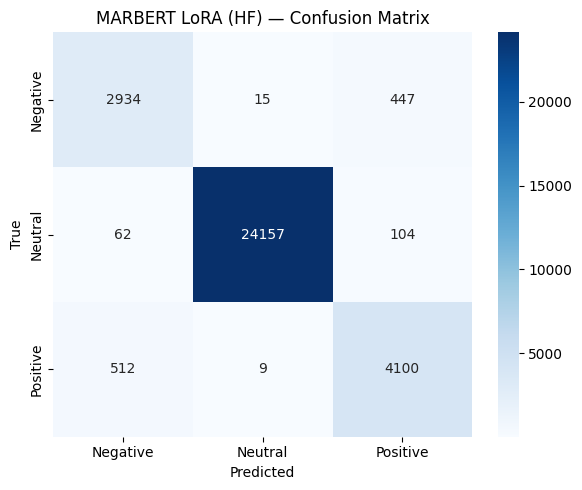

In [24]:
plot_trainer_history(trainer_mar_lora, 'MARBERT LoRA (HF)')
f1_mar_lora, acc_mar_lora, preds_mar_lora, _ = full_evaluation(
    trainer_mar_lora, mar_test_ds, 'MARBERT LoRA (HF)'
)

## 5. Cross-Framework Comparison

In [25]:
# ── HuggingFace Trainer results ───────────────────────────────────
hf_results = pd.DataFrame({
    'Model'         : ['XLM-RoBERTa', 'XLM-RoBERTa', 'MARBERT', 'MARBERT'],
    'Strategy'      : ['Full FT', 'LoRA', 'Full FT', 'LoRA'],
    'Framework'     : ['HF Trainer', 'HF Trainer', 'HF Trainer', 'HF Trainer'],
    'Test Macro F1' : [round(f1_xlm_full, 4), round(f1_xlm_lora, 4),
                       round(f1_mar_full, 4), round(f1_mar_lora, 4)],
    'Accuracy'      : [round(acc_xlm_full, 4), round(acc_xlm_lora, 4),
                       round(acc_mar_full, 4), round(acc_mar_lora, 4)],
})

# ── PyTorch results (from Notebook 01 — fill these in manually) ───
pytorch_results = pd.DataFrame({
    'Model'         : ['XLM-RoBERTa', 'XLM-RoBERTa', 'MARBERT', 'MARBERT'],
    'Strategy'      : ['Full FT', 'LoRA Scratch', 'Full FT', 'LoRA Scratch'],
    'Framework'     : ['PyTorch', 'PyTorch', 'PyTorch', 'PyTorch'],
    'Test Macro F1' : [0.8989, 0.8912, 0.9122, 0.9094],  # ← from Notebook 01
    'Accuracy'      : [0.96, 0.96, 0.97, 0.96],  # ← from Notebook 01
})

combined = pd.concat([pytorch_results, hf_results], ignore_index=True)
print('=== CROSS-FRAMEWORK COMPARISON ===')
print(combined.to_string(index=False))

combined.to_csv('hf_outputs/cross_framework_comparison.csv', index=False)
print('\nSaved: hf_outputs/cross_framework_comparison.csv')

=== CROSS-FRAMEWORK COMPARISON ===
      Model     Strategy  Framework  Test Macro F1  Accuracy
XLM-RoBERTa      Full FT    PyTorch         0.8989    0.9600
XLM-RoBERTa LoRA Scratch    PyTorch         0.8912    0.9600
    MARBERT      Full FT    PyTorch         0.9122    0.9700
    MARBERT LoRA Scratch    PyTorch         0.9094    0.9600
XLM-RoBERTa      Full FT HF Trainer         0.8957    0.9592
XLM-RoBERTa         LoRA HF Trainer         0.8968    0.9596
    MARBERT      Full FT HF Trainer         0.9065    0.9634
    MARBERT         LoRA HF Trainer         0.9101    0.9645

Saved: hf_outputs/cross_framework_comparison.csv


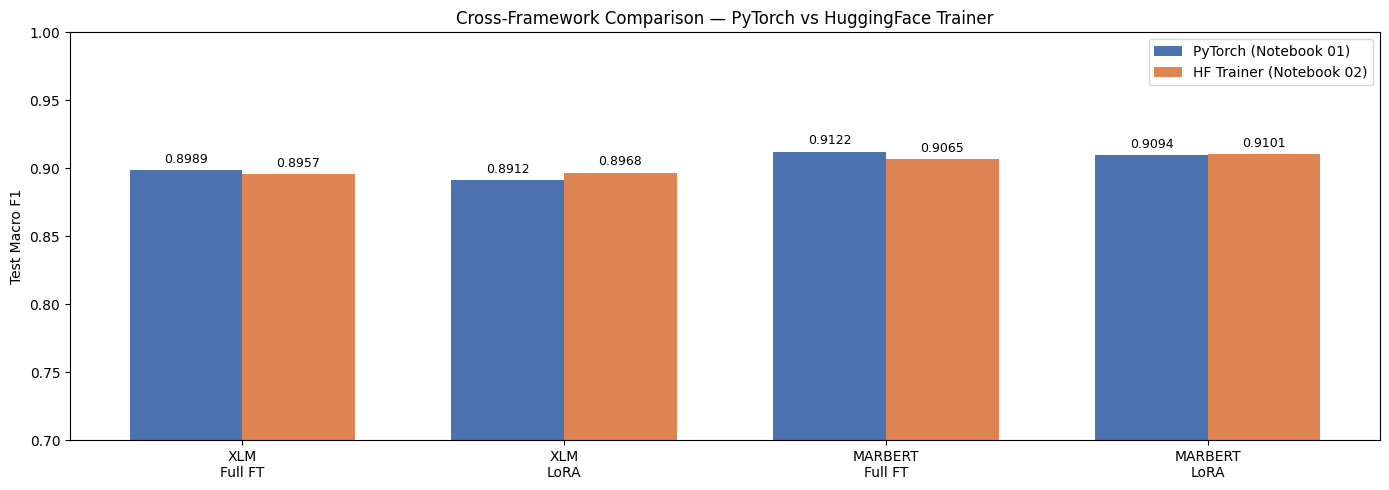


Key finding: Both frameworks produce similar results.
Difference in Macro F1 (PyTorch vs HF Trainer):
  XLM Full FT: 0.0032
  XLM LoRA: 0.0056
  MARBERT Full FT: 0.0057
  MARBERT LoRA: 0.0007


In [26]:
# ── Cross-framework comparison chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

pytorch_f1 = [0.8989, 0.8912, 0.9122, 0.9094]
hf_f1      = [f1_xlm_full, f1_xlm_lora, f1_mar_full, f1_mar_lora]
labels_exp = ['XLM\nFull FT', 'XLM\nLoRA', 'MARBERT\nFull FT', 'MARBERT\nLoRA']

x     = np.arange(len(labels_exp))
width = 0.35

bars1 = ax.bar(x - width/2, pytorch_f1, width, label='PyTorch (Notebook 01)', color='#4C72B0')
bars2 = ax.bar(x + width/2, hf_f1,      width, label='HF Trainer (Notebook 02)', color='#DD8452')

ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels_exp)
ax.set_ylabel('Test Macro F1')
ax.set_ylim(0.7, 1.0)
ax.set_title('Cross-Framework Comparison — PyTorch vs HuggingFace Trainer')
ax.legend()
plt.tight_layout()
plt.savefig('hf_outputs/cross_framework_chart.png', dpi=150)
plt.show()

print('\nKey finding: Both frameworks produce similar results.')
print('Difference in Macro F1 (PyTorch vs HF Trainer):')
for i, name in enumerate(labels_exp):
    diff = abs(pytorch_f1[i] - hf_f1[i])
    print(f'  {name.replace(chr(10)," ")}: {diff:.4f}')

In [27]:
# ── Save everything to Google Drive ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import shutil
DRIVE_DIR = '/content/drive/MyDrive/arabic-english-sentiment-analysis-trained-models'
os.makedirs(DRIVE_DIR, exist_ok=True)

# Save HF trainer checkpoints
for folder in ['hf_outputs/xlm_full', 'hf_outputs/xlm_lora',
               'hf_outputs/marbert_full', 'hf_outputs/marbert_lora']:
    # Find the best checkpoint inside each folder
    p = Path(folder)
    checkpoints = sorted(p.glob('checkpoint-*'), key=lambda x: int(x.name.split('-')[-1]))
    if checkpoints:
        best_ckpt = checkpoints[-1]
        dest = Path(DRIVE_DIR) / f'hf_{p.name}_best'
        if dest.exists(): shutil.rmtree(dest)
        shutil.copytree(best_ckpt, dest)
        print(f'✓ Saved: {best_ckpt.name} → {dest}')

# Save results CSV
shutil.copy('hf_outputs/cross_framework_comparison.csv',
            f'{DRIVE_DIR}/cross_framework_comparison.csv')
print('Saved: cross_framework_comparison.csv')
print(f'\nAll saved to: {DRIVE_DIR}')

Mounted at /content/drive
✓ Saved: checkpoint-27705 → /content/drive/MyDrive/arabic-english-sentiment-analysis-trained-models/hf_xlm_full_best
✓ Saved: checkpoint-27705 → /content/drive/MyDrive/arabic-english-sentiment-analysis-trained-models/hf_xlm_lora_best
✓ Saved: checkpoint-27705 → /content/drive/MyDrive/arabic-english-sentiment-analysis-trained-models/hf_marbert_full_best
✓ Saved: checkpoint-27705 → /content/drive/MyDrive/arabic-english-sentiment-analysis-trained-models/hf_marbert_lora_best
Saved: cross_framework_comparison.csv

All saved to: /content/drive/MyDrive/arabic-english-sentiment-analysis-trained-models
